In [10]:
import re
uniq = set()
with open("./process_result/cadets-e5/val_uuid2feture.txt", "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        values = line.split("$")
        if len(values) > 4:
            # مقدار بعد از آخرین $
            value = values[4]
            uniq.add(value)

def extract_num(path):
    m = re.search(r'\.bin\.(\d+)\.json', path)
    if m:
        return int(m.group(1))
    return 999999  # اگر پیدا نشد، آخر لیست قرار گیرد

# مرتب‌سازی عددی
sorted_paths = sorted(uniq, key=extract_num)

for p in sorted_paths:
    print(p)

../dataset/cadets-e5/ta1-cadets-1-e5-official-2.bin.53.json.1
../dataset/cadets-e5/ta1-cadets-1-e5-official-2.bin.53.json
../dataset/cadets-e5/ta1-cadets-1-e5-official-2.bin.54.json.1
../dataset/cadets-e5/ta1-cadets-1-e5-official-2.bin.54.json
../dataset/cadets-e5/ta1-cadets-1-e5-official-2.bin.55.json
../dataset/cadets-e5/ta1-cadets-1-e5-official-2.bin.55.json.1
../dataset/cadets-e5/ta1-cadets-1-e5-official-2.bin.56.json.1
../dataset/cadets-e5/ta1-cadets-1-e5-official-2.bin.56.json
../dataset/cadets-e5/ta1-cadets-1-e5-official-2.bin.57.json.1
../dataset/cadets-e5/ta1-cadets-1-e5-official-2.bin.57.json
../dataset/cadets-e5/ta1-cadets-1-e5-official-2.bin.58.json
../dataset/cadets-e5/ta1-cadets-1-e5-official-2.bin.58.json.1
../dataset/cadets-e5/ta1-cadets-1-e5-official-2.bin.59.json.1
../dataset/cadets-e5/ta1-cadets-1-e5-official-2.bin.59.json
../dataset/cadets-e5/ta1-cadets-1-e5-official-2.bin.60.json
../dataset/cadets-e5/ta1-cadets-1-e5-official-2.bin.60.json.1
../dataset/cadets-e5/ta1

In [1]:
import argparse
import os.path as osp
import os
import argparse
import torch
import time
from torch_geometric.loader import NeighborLoader
from utils.model import * 
from utils.config import get_test_dataset
def evaluate (gt ,  alarms , tot_node , print_result=False):
	eps = 1e-10
	tn = 0
	tp = 0
	fn = 0
	fp = 0
	for x in alarms:
		if x in gt: tp +=1
		else : fp +=1
	for x in gt:
		if x not in alarms : fn +=1
	tn = tot_node - tp -fp -fn


	precision = tp/(tp+fp+eps)
	recall = tp/(tp+fn+eps)
	fscore = 2*precision*recall/(precision+recall+eps)
	numerator = (tp * tn) - (fp * fn)
	# denominator = np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
	# if denominator == 0:
	# 	mcc = 0 
	# else:    
	# 	mcc = numerator / denominator
	beta = 2
	beta_sq = beta ** 2	
	fbeta = (1 + beta_sq) * (precision * recall) / ((beta_sq * precision) + recall + eps)
	if print_result:
		print('tp,fp,tn,fn')
		print(tp,fp,tn,fn)
		print('Precision: ', precision)
		print('Recall: ', recall)
		print('F-Score: ', fscore)
		print('Fbeta-Score: ', fbeta)
		# print('MCC: ', mcc)
	return fbeta


# name = 'theia-e5'
# name = 'theia-e3'
name = 'clear-e5'
b_size = 1000
path = get_test_dataset(name)

in_channels = 128
hidden_channels = 32
data, adj, nodeID , feature_dic  , data1 = TestDatasetA(path , name , in_channels , 'android')


device = torch.device('cuda')

autoencoder = GNNAutoencoder(in_channels, hidden_channels)
	

71230
./dataset/clear-e5/ta1-clearscope-2-e5-official-1.bin.19.json
./dataset/clear-e5/ta1-clearscope-2-e5-official-1.bin.19.json.1
./dataset/clear-e5/ta1-clearscope-2-e5-official-1.bin.20.json
./dataset/clear-e5/ta1-clearscope-2-e5-official-1.bin.20.json.1
./dataset/clear-e5/ta1-clearscope-2-e5-official-1.bin.21.json
./dataset/clear-e5/ta1-clearscope-2-e5-official-1.bin.21.json.1
./dataset/clear-e5/ta1-clearscope-2-e5-official-1.bin.22.json
./dataset/clear-e5/ta1-clearscope-2-e5-official-1.bin.22.json.1
./dataset/clear-e5/ta1-clearscope-2-e5-official-1.bin.23.json
./dataset/clear-e5/ta1-clearscope-2-e5-official-1.bin.23.json.1
./dataset/clear-e5/ta1-clearscope-2-e5-official-1.bin.28.json
./dataset/clear-e5/ta1-clearscope-2-e5-official-1.bin.28.json.1
./dataset/clear-e5/ta1-clearscope-2-e5-official-1.bin.29.json
./dataset/clear-e5/ta1-clearscope-2-e5-official-1.bin.29.json.1
./dataset/clear-e5/ta1-clearscope-2-e5-official-1.bin.30.json
./dataset/clear-e5/ta1-clearscope-2-e5-official-1.

c:\Users\Asus\Desktop\codes\Targeter-final\utils\model.py:210: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ..\torch\csrc\utils\tensor_new.cpp:278.)
  x = torch.tensor(x_list, dtype=torch.float)	#بردار نودها


In [2]:

from collections import Counter
import re
import heapq
files_count = Counter()
pathname = f"./models/{name}/"
alarm =  open(f"./process_result/{name}/alarm.txt", "w" , encoding="utf-8") 
alarm2 =  open(f"./process_result/{name}/alarm2.txt", "w", encoding="utf-8") 
attack = open(f"./process_result/{name}/attack.txt", "w" , encoding="utf-8") 
anomaly_threshold  = {}
with open(f"{pathname}thre.txt", "r", encoding="utf-8") as f:  # جایگزین با نام فایل واقعی
		for line in f:
			key, value= line.strip().split(" : ")  # جدا کردن کلید و مقدار
			numbers = re.findall(r'[-+]?\d*\.\d+|\d+', value)
			anomaly_threshold [int(key)] = float(numbers[0])#float(value)# 
# if name == 'theia-e5':
	# last_key = list(anomaly_threshold)[-1]
anomaly_threshold[8] = 0.6526572704315186
with open(f"./process_result/{name}/groundtruth.txt", "r") as f1:
		GT = set(line.strip() for line in f1)  # تبدیل به مجموعه برای جستجوی سریع

positive = set()
reversed_nodeId = {v: k for k, v in nodeID.items()}
files = set()
scores = {}
cat_len = {
			'unix':21,
			'android' : 18
			}
system = 'android'
for t in  range(17):
# # 		tpositive = {}
		j = t + 1
		anomaly_scores = {}
		alarm.write('#######################start' + str(j)+ '\n')
		for i in range (len(data.test_mask)):
			data.test_mask[i] = False
		
		for i in range (len(data.test_mask)):
				if (data.y[i] == j  ):
					data.test_mask[i] = True
		print(f'{j} : {data.test_mask.sum().item()}')
		if (data.test_mask.sum().item() > 0 ):
				model_path = f'{pathname}model_'+str(j)
				if os.path.exists(model_path):
					autoencoder.load_state_dict(torch.load(model_path))
				else:
					model_path = f'./models/{name}/model_'+str(cat_len[system])
					anomaly_threshold[j] = anomaly_threshold[cat_len[system]] 
					autoencoder.load_state_dict(torch.load(model_path))
				autoencoder.load_state_dict(torch.load(model_path))
				autoencoder.eval()
				loader = NeighborLoader( data, num_neighbors=[-1, -1  , -1], batch_size=b_size, input_nodes = data.test_mask, shuffle=False)
				for batch in loader:
					x_recon, z = autoencoder(batch.x, batch.edge_index)
					batch_anomaly_scores = torch.norm(x_recon - batch.x, dim=1)
					y = batch.y.to(device)
					for i, node_id in enumerate(batch.n_id):
						uuid = nodeID[int(node_id)]
						meval = True if (uuid) in GT else False
						score = batch_anomaly_scores[i].item()
						if meval == True and y[i] == j  :
							attack.write(f'{uuid} : {y[i]} : {score} : {anomaly_threshold[j]} : {feature_dic[uuid].strip()}\n')
						
						if  y[i] == j : # and  feature_dic[uuid].strip() != '' :
							# alarm2.write(f'{uuid} $ {y[i]} $ {score} $ {anomaly_threshold[j]} $ {feature_dic[uuid].strip()} $ {meval} \n')
							scores[uuid] = (score , y[i])
						if score > anomaly_threshold[j]*1.9 and   feature_dic[uuid].strip() != ''and reversed_nodeId[uuid] in adj.keys():
							if y[i] == j  :
								positive.add(uuid)
								alarm.write(f'{uuid} $ {y[i]} $ {score} $ {anomaly_threshold[j]} $ {feature_dic[uuid].strip()} $ {meval} \n')
					


alarm.close()
alarm2.close()
attack.close()

evaluate( GT , positive , len(data.test_mask) , True)
files_count_filter = [uuid for uuid in files_count if files_count[uuid] > 0]
	

1 : 93
2 : 11
3 : 4
4 : 27
5 : 95
6 : 13
7 : 0
8 : 10
9 : 7739
10 : 0
11 : 0
12 : 1001
13 : 9082
14 : 49431
15 : 0
16 : 0
17 : 3724
tp,fp,tn,fn
9 231 70977 13
Precision:  0.03749999999998438
Recall:  0.4090909090890496
F-Score:  0.06870229006089972
Fbeta-Score:  0.13719512192647143


In [3]:
anomaly_threshold

{1: 1.7966794967651367,
 2: 0.8037164211273193,
 3: 0.2335960566997528,
 4: 0.6733932495117188,
 5: 0.9201905131340027,
 6: 1.369852900505066,
 8: 0.6526572704315186,
 9: 1.9001502990722656,
 12: 2.0325539350509643,
 13: 1.6821789622306822,
 14: 1.6750398874282837,
 17: 0.12750516831874847,
 18: 2.361879634857178}

In [3]:

max = 0
savei = 0
thresholds = {uuid: anomaly_threshold[int(group)] for uuid, (_, group) in scores.items()}

best_fbeta = float('-inf')
best_i = 1
reversed_nodeId = {v: k for k, v in nodeID.items()}
for i in range(5, 21):
    positive = {uuid for uuid, (score, _) in scores.items() if (score > thresholds[uuid] * i/10 and reversed_nodeId[uuid] in adj.keys())}
    
    fbeta = evaluate(GT, positive, len(data.test_mask))

    if fbeta > best_fbeta:
        best_fbeta = fbeta
        best_i = i
fbest_i = best_i



positive = {uuid for uuid, (score, _) in scores.items() if (score > thresholds[uuid] * 20/10 and reversed_nodeId[uuid] in adj.keys())}

print(fbest_i)

                  
fbeta = evaluate( GT , positive , len(data.test_mask) , True)

14
tp,fp,tn,fn
19 1311 79577 22
Precision:  0.014285714285713211
Recall:  0.46341463414521117
F-Score:  0.027716994888431566
Fbeta-Score:  0.06358768405737518


In [7]:
print(len(positive))

21426


In [35]:
import networkx as nx
from torch_geometric.utils import to_networkx
from torch_geometric.utils import subgraph
from tqdm import tqdm
G = to_networkx(data1, to_undirected=True)
positive_indices = [reversed_nodeId[uuid] for uuid in positive]


subgraph_nodes = set()



for i in tqdm(range(len(positive_indices))):
    for j in range( i + 1, len(positive_indices)):
        try:
            path = nx.shortest_path(G, positive_indices[i], positive_indices[j])
            subgraph_nodes.update(path)
        except nx.NetworkXNoPath:
            continue



# ایجاد ماسک برای استخراج نودهای زیرگراف
subgraph_nodes = list(subgraph_nodes)

subgraph_nodes_original = [int(i) for i in subgraph_nodes]

# تبدیل به UUID
final_uuids = [nodeID[i] for i in subgraph_nodes_original]
evaluate( GT , final_uuids , len(data.test_mask) , True)

100%|██████████| 1531/1531 [07:37<00:00,  3.35it/s] 

tp,fp,tn,fn
35 2116 212656 37
Precision:  0.016271501627149406
Recall:  0.4861111111104359
F-Score:  0.03148897885112915
Fbeta-Score:  0.07175071749414311


0.07175071749414311

In [36]:
from collections import Counter
import networkx as nx
from torch_geometric.utils import to_networkx
from torch_geometric.utils import subgraph
from tqdm import tqdm
second_positive = set ()
mylist = set()
dic = {}
for x in tqdm(final_uuids) :
		all_counts = Counter()
		x = reversed_nodeId[x]
		if x in adj.keys():
			for k in adj[x]:
				if nodeID[k] in positive:
					all_counts[k] += 1
				else:
					if k in adj.keys():
						for kk in adj[k]:
							if nodeID[kk] in positive and kk !=x :
								all_counts[kk] += 1		
		# print(len(all_counts))
		dic [nodeID[x]] = (all_counts)
		if len(all_counts) >  2:
			second_positive.add(nodeID[x])


evaluate( GT , second_positive , len(data.test_mask), True)

100%|██████████| 2151/2151 [00:19<00:00, 108.44it/s]

tp,fp,tn,fn
33 1926 212846 39
Precision:  0.016845329249616292
Recall:  0.45833333333269677
F-Score:  0.03249630723097193
Fbeta-Score:  0.0734312416415565


0.0734312416415565

In [1]:
import numpy as np
def evaluate2 (tp,fp,tn,fn):

	precision = tp/(tp+fp)
	recall = tp/(tp+fn)
	fscore = 2*precision*recall/(precision+recall)
	numerator = (tp * tn) - (fp * fn)
	denominator = np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
	if denominator == 0:
		mcc = 0 
	else:    
		mcc = numerator / denominator
	beta = 2
	beta_sq = beta ** 2	
	fbeta = (1 + beta_sq) * (precision * recall) / ((beta_sq * precision) + recall)
	print('Precision: ', precision)
	print('Recall: ', recall)
	print('F-Score: ', fscore)
	print('Fbeta-Score: ', fbeta)
	print('MCC: ', mcc)
evaluate2(19,	9	,735478	,99)


Precision:  0.6785714285714286
Recall:  0.16101694915254236
F-Score:  0.2602739726027397
Fbeta-Score:  0.18999999999999997
MCC:  0.3305019339379224


In [3]:
def accuracy_score_manual(tp , fp , tn , fn):
    correct = tp + tn 
    return correct / (tp + fp + tn + fn )

print(accuracy_score_manual(34, 1937, 78951, 7))
print(accuracy_score_manual(19 , 9 ,735478 , 99))

0.9759789445069135
0.9998531820746188


In [59]:
from collections import Counter

# مسیر فایل
file_path = "./process_result/theia-e3/train_uuid2feture.txt"

# شمارنده برای مقدار چهارم (یعنی ستون با index 3، یعنی $0, $1, $2, $3 → ستون چهارم)
count = Counter()
num_values = 0 
# خواندن فایل و استخراج مقادیر مورد نظر
with open(file_path, 'r') as f:
    for line in f:
        parts = line.strip().split('$')
        if len(parts) > 3 and parts[2] != '0':
            count[parts[2]] += 1
            num_values += 1

# چاپ نتایج
for key in sorted(count):
    print(f"مقدار {key} تعداد {count[key]/num_values:.2f} بار تکرار شده است. {count[key]}")


مقدار 1 تعداد 0.05 بار تکرار شده است. 4744
مقدار 10 تعداد 0.06 بار تکرار شده است. 5914
مقدار 11 تعداد 0.04 بار تکرار شده است. 3808
مقدار 12 تعداد 0.13 بار تکرار شده است. 12208
مقدار 13 تعداد 0.01 بار تکرار شده است. 1046
مقدار 2 تعداد 0.01 بار تکرار شده است. 886
مقدار 3 تعداد 0.01 بار تکرار شده است. 607
مقدار 4 تعداد 0.15 بار تکرار شده است. 14289
مقدار 5 تعداد 0.03 بار تکرار شده است. 3215
مقدار 6 تعداد 0.40 بار تکرار شده است. 37395
مقدار 7 تعداد 0.03 بار تکرار شده است. 2817
مقدار 8 تعداد 0.05 بار تکرار شده است. 4804
مقدار 9 تعداد 0.01 بار تکرار شده است. 643


In [68]:
import os
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np
from utils.Word2Vec_embedding import tokenize
from gensim.models import Word2Vec
def sentence_vector(sentence , word2vec_model):
	tokens = tokenize(sentence)
	vectors = [word2vec_model.wv[word] for word in tokens if word in word2vec_model.wv]
	return np.mean(vectors, axis=0) if vectors else np.zeros(word2vec_model.vector_size)
files =  [
            './dataset/theia-e3/ta1-theia-e3-official-1r.json',
			  './dataset/theia-e3/ta1-theia-e3-official-1r.json.1',
			  './dataset/theia-e3/ta1-theia-e3-official-1r.json.2',
			  './dataset/theia-e3/ta1-theia-e3-official-1r.json.3',
			  './dataset/theia-e3/ta1-theia-e3-official-1r.json.4',
			  './dataset/theia-e3/ta1-theia-e3-official-1r.json.5',
               './dataset/theia-e3/ta1-theia-e3-official-1r.json.6',
                './dataset/theia-e3/ta1-theia-e3-official-1r.json.7',
                 './dataset/theia-e3/ta1-theia-e3-official-1r.json.8',
                  './dataset/theia-e3/ta1-theia-e3-official-1r.json.9',]

# گراف بدون جهت (یا جهت‌دار؟ به دلخواهت!)
G = nx.Graph()

# خواندن و ساخت گراف
for file in files:
    with open(file +'.txt', 'r') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) >= 3:
                src, dst = parts[0], parts[1]
                G.add_edge(src, dst)

label_dict = {}
feature_dic = {}
# فرض: label_dict به شکل label_dict[uuid] = 6 یا 8
# feature_dic و word2vec_model هم تعریف شده
with open("./process_result/theia-e3/train_uuid2feture.txt", "r" ,  encoding='utf-8') as file:
		for line in file:
			if len(line.split('$')) >3:
				result=line.split('$')
				uuid=result[0]
				group=result[2]
				feature=result[3]
				feature_dic[uuid] =feature
				label_dict[uuid] = int(group)
file.close
target_labels = range (1, 14)
target_nodes = [node for node in G.nodes if label_dict.get(node) in target_labels]

# بردار اولیه نودها
x_list = []
labels = []

def get_feature_vector(uuid):
    return sentence_vector(feature_dic[uuid], word2vec_model)
word2vec_model = Word2Vec.load('./models/theia-e3/word2vec-embedding_128.model')
# بردار نهایی = میانگین بردار خود نود + بردار همسایه‌ها




In [69]:
for node in target_nodes:
    try:
        own_vec = get_feature_vector(node)
        neighbors = list(G.neighbors(node)) 
        neighbor_vecs = []

        for n in neighbors:
            if n in feature_dic:
                neighbor_vecs.append(get_feature_vector(n))

        if neighbor_vecs:
            all_vecs = [own_vec] + neighbor_vecs
            final_vec = np.mean(all_vecs, axis=0)
        else:
            final_vec = own_vec

        x_list.append(final_vec)
        labels.append(label_dict[node])

    except KeyError:
        continue  # اگر UUID در feature_dic نبود، رد می‌کنیم





pca = PCA(n_components=2)
x_2d = pca.fit_transform(x_list)


In [72]:
unique_labels

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]

In [75]:
colormap(0)

(0.12156862745098039, 0.4666666666666667, 0.7058823529411765, 1.0)

C:\Users\Asus\AppData\Local\Temp\ipykernel_5724\2189473535.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colormap = cm.get_cmap('tab20', 13)


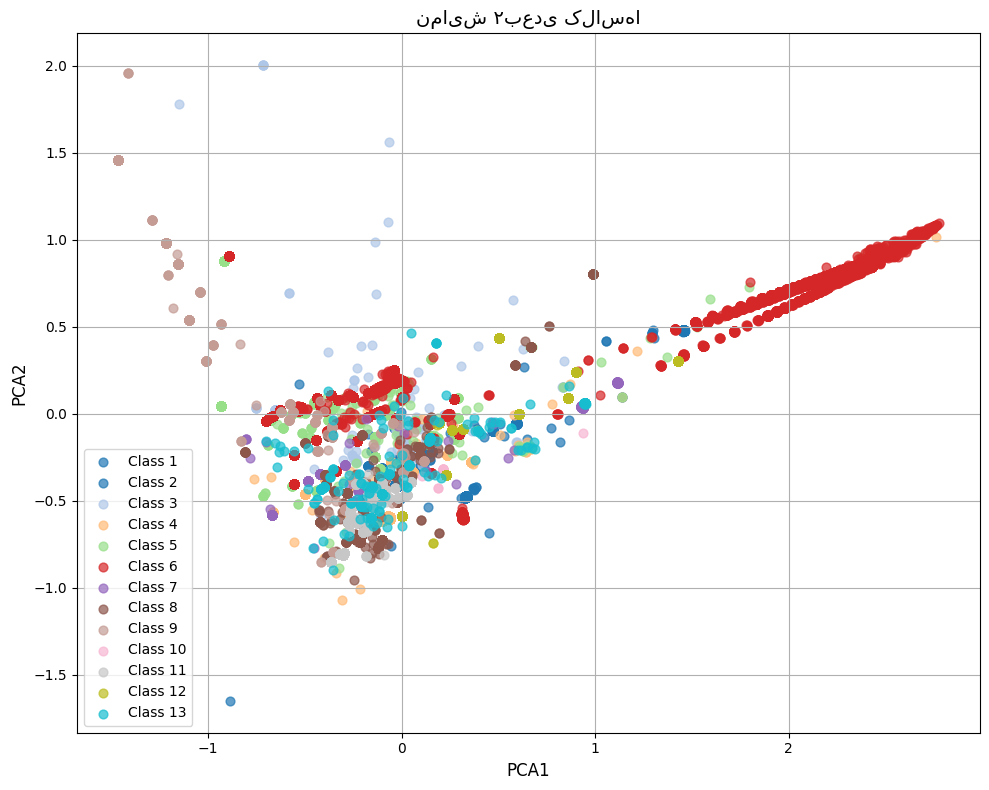

In [76]:
import matplotlib.cm as cm
unique_labels = sorted(set(labels))  # یا همون range(12) اگر مطمئنی فقط ۱۲ تا کلاس هست
colormap = cm.get_cmap('tab20', 13) 
colors = {label: colormap(i-1) for i, label in enumerate(unique_labels)}
x_2d = np.array(x_2d)
labels = np.array(labels)
plt.figure(figsize=(10, 8))  # به جای (10, 8) عددهای دلخواه بگذار

for j in range(13):
    class_label = j+1
    indices = (labels == class_label)
    plt.scatter(x_2d[indices, 0], x_2d[indices, 1],
                color=colors[class_label],
                label=f'Class {class_label}',
                alpha=0.7,
                s=40)  # s=اندازه‌ی نقطه‌ها (اختیاری برای بزرگ‌تر کردنشان)

handles, lbls = plt.gca().get_legend_handles_labels()
by_label = dict(zip(lbls, handles))
plt.legend(by_label.values(), by_label.keys(), loc='best', fontsize=10)

plt.xlabel('PCA1', fontsize=12)
plt.ylabel('PCA2', fontsize=12)
plt.title('نمایش ۲بعدی کلاس‌ها', fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()


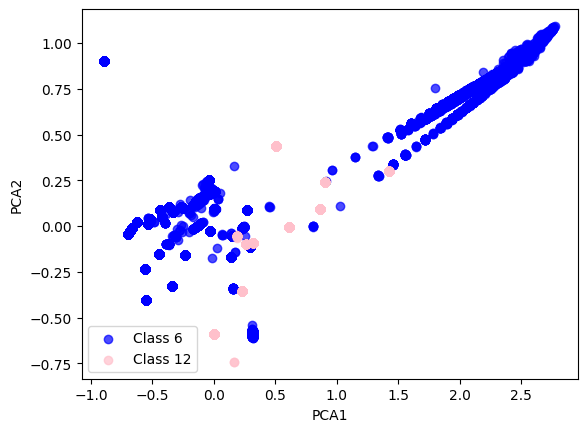

In [77]:
colors = {9: 'green' ,11: 'red', 6: 'blue' , 12:'pink'}
x_2d = np.array(x_2d)
labels = np.array(labels)
for class_label in [ 6,12]:
    indices = (labels == class_label)
    plt.scatter(x_2d[indices, 0], x_2d[indices, 1],
                color=colors[class_label],
                label=f'Class {class_label}',
                alpha=0.7)
handles, lbls = plt.gca().get_legend_handles_labels()
by_label = dict(zip(lbls, handles))
plt.legend(by_label.values(), by_label.keys())

# plt.title('Class Separation in PCA Space (Class 6 vs Class 11)')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
# plt.grid(True)
plt.show()

In [63]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# فرض: x_2d داده‌های PCA شده، labels برچسب کلاس‌ها
X_train, X_test, y_train, y_test = train_test_split(x_2d, labels, test_size=0.3, random_state=42)

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

# نتایج عددی
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.9976886370414554
              precision    recall  f1-score   support

           1       1.00      1.00      1.00      1432
           2       0.98      0.98      0.98       265
           3       0.97      0.96      0.96       182
           4       1.00      1.00      1.00      4226
           5       0.99      0.99      0.99       964
           6       1.00      1.00      1.00     11209
           7       1.00      0.99      0.99       849
           8       0.99      0.99      0.99       970
           9       0.98      0.98      0.98       187
          10       1.00      1.00      1.00      1735
          11       1.00      1.00      1.00      1115
          12       1.00      1.00      1.00      3690

    accuracy                           1.00     26824
   macro avg       0.99      0.99      0.99     26824
weighted avg       1.00      1.00      1.00     26824



In [3]:
import os
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np
from utils.Word2Vec_embedding import tokenize
from gensim.models import Word2Vec
def sentence_vector(sentence , word2vec_model):
	tokens = tokenize(sentence)
	vectors = [word2vec_model.wv[word] for word in tokens if word in word2vec_model.wv]
	return np.mean(vectors, axis=0) if vectors else np.zeros(word2vec_model.vector_size)

label_dict = {}
feature_dic = {}
with open("./process_result/theia-e3/train_uuid2feture.txt", "r" ,  encoding='utf-8') as file:
		for line in file:
			if len(line.split('$')) >3:
				result=line.split('$')
				uuid=result[0]
				group=result[2]
				feature=result[3]
				feature_dic[uuid] =feature
				label_dict[uuid] = int(group)
                            
files =  [
            './dataset/theia-e3/ta1-theia-e3-official-1r.json',
			  './dataset/theia-e3/ta1-theia-e3-official-1r.json.1',
			  './dataset/theia-e3/ta1-theia-e3-official-1r.json.2',
			  './dataset/theia-e3/ta1-theia-e3-official-1r.json.3',
			  './dataset/theia-e3/ta1-theia-e3-official-1r.json.4',
			  './dataset/theia-e3/ta1-theia-e3-official-1r.json.5',
               './dataset/theia-e3/ta1-theia-e3-official-1r.json.6',
                './dataset/theia-e3/ta1-theia-e3-official-1r.json.7',
                 './dataset/theia-e3/ta1-theia-e3-official-1r.json.8',
                  './dataset/theia-e3/ta1-theia-e3-official-1r.json.9',]

names = set()
# خواندن و ساخت گراف
for file in files:
    with open(file +'.txt', 'r') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) >= 3:
                src, dst = parts[0], parts[1]
                if label_dict[src]== 11 :
                      names.add(feature_dic[dst])
                if label_dict[dst]== 11 :
                      names.add(feature_dic[src])






In [2]:
names  # firefox

{'',
 '/run/shm/org.chromium.dioVXf',
 '/run/shm/org.chromium.4kjqzW',
 '128.55.12.110 : 42453 to 64.191.208.114 : 80',
 '128.55.12.110 : 37525 to 67.28.122.168 : 80',
 '128.55.12.110 : 41304 to 128.55.12.10 : 53',
 '/run/shm/org.chromium.qDN3I0',
 '128.55.12.110 : 52208 to 66.151.183.41 : 80',
 '128.55.12.110 : 37790 to 208.75.170.1 : 80',
 '128.55.12.110 : 48317 to NA : 0',
 '128.55.12.110 : 38916 to 128.55.12.10 : 53',
 '/run/shm/org.chromium.JsZnZy',
 '128.55.12.110 : 44435 to NA : 0',
 '128.55.12.110 : 40713 to 128.55.12.10 : 53',
 '/run/shm/org.chromium.GpG3CG',
 '128.55.12.110 : 42494 to 12.149.161.245 : 80',
 '/run/shm/org.chromium.Ei3Rk7',
 '128.55.12.110 : 50737 to 208.75.170.1 : 80',
 '128.55.12.110 : 58853 to 128.55.12.10 : 53',
 '/run/shm/org.chromium.V5w3A8',
 '/run/shm/org.chromium.1XD58m',
 '/run/shm/org.chromium.9vM72y',
 '128.55.12.110 : 58196 to 64.191.208.114 : 80',
 '/run/shm/org.chromium.dUR6pv',
 '/run/shm/org.chromium.3QxmjW',
 '/run/shm/org.chromium.UmtRBN',
 '

In [4]:
names

{'/bin/cat',
 '/bin/date',
 '/bin/grep',
 '/bin/ls',
 '/bin/sed',
 '/bin/uname',
 '/etc/bash_completion',
 '/etc/bash_completion.d',
 '/etc/ntp.conf',
 '/home/theia/theia-es/eglibc-2.15/prefix/lib/libc-2.15.so',
 '/home/theia/theia-es/eglibc-2.15/prefix/lib/libdl-2.15.so',
 '/home/theia/theia-es/eglibc-2.15/prefix/lib/libpthread-2.15.so',
 '/home/theia/theia-es/eglibc-2.15/prefix/lib/librt-2.15.so',
 '/home/theia/theia-es/eglibc-2.15/prefix/share/locale/locale.alias',
 '/home/theia/theia-es/eglibc-2.15/prefix/share/zoneinfo/Factory',
 '/lib/x86_64-linux-gnu/libacl.so.1.1.0',
 '/lib/x86_64-linux-gnu/libattr.so.1.1.0',
 '/lib/x86_64-linux-gnu/libselinux.so.1',
 '/proc/filesystems',
 '/proc/meminfo',
 '/run/motd.new',
 '/run/resolvconf/interface/eth1.dhclient',
 '/usr/bin/sort',
 '/var/lib/update-notifier/fsck-at-reboot',
 '/var/lib/update-notifier/hwe-eol',
 '/var/lib/update-notifier/release-upgrade-available',
 '/var/lib/update-notifier/updates-available',
 'N/A'}